# GF/PA6 Hybrid Sandwich — Flexural Analysis (rewritten)

End-to-end pipeline:

1. Load force–displacement CSVs and the dimension book.
2. Identify the linear region of each load–displacement record by rolling-R² and fit `k` directly on raw data (no x-axis shift).
3. IQR-screen specimen-level `k` per (thickness, span); compute group means.
4. Apply ASTM D7250 inversion for `D`, `U`; compute `G` from cross-section dimensions.
5. Back-calculate face-sheet modulus `E_face` per thickness; compare against ROM-predicted `E_face ≈ 20 GPa`.
6. Process the 6 mm pellet-only plaque as a monolithic Euler–Bernoulli beam at each span; compare against the 6 mm sandwich.

All stiffness quantities (`D`, `U`, `G`, `E_face`) are plotted against the actual measured total thickness `d` (mm), not nominal thickness or core thickness `c`.


## 1. Imports & configuration

In [25]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)


In [26]:
# ── CONFIGURATION ────────────────────────────────────────────────────────────
DATA_FOLDER       = Path(".")           # CSVs and dimension book live here
DIMENSION_BOOK    = DATA_FOLDER / "Dimension Book - Flexural Testing GFPA6 Sandwhich(Flexural Testing Dimensions).csv"

R2_THRESHOLD      = 0.998               # rolling R² threshold for linear region detection
WINDOW_SIZE       = 30                  # rolling window size (rows)
IQR_FENCE         = 1.5                 # outlier fence on per-specimen k
RANDOM_SEED       = 42

THICKNESSES       = ["2mm", "3mm", "4mm", "6mm", "8mm"]
SS_3MM_SOURCE     = "alt"               # "main" → hybrid_3mm_ss_s*.csv; "alt" → hybrid_3mm2_ss_s*.csv
                                        # NOTE: the original 3mm SS set is wrong; always use "alt".

FACE_THICKNESS    = 0.72                # mm (one facing)

# 2 mm panel is non-physical (k_SS/k_LS sits at the singularity of the ASTM
# inversion). Keep in tables with a flag; exclude from plots.
EXCLUDE_FROM_PLOTS = {"2mm"}

# Constituent moduli for ROM-based theoretical face modulus
E_GLASS_GPA       = 72.0
E_PA6_GPA         = 2.7
VF_FACE           = 0.46                # from JM Neomera 886 material card

# Units convention (matching the original notebook):
#   k:       N/mm
#   D:       N·mm²
#   U:       N
#   G:       MPa
#   E_face:  GPa

print(f"R²>={R2_THRESHOLD}, window={WINDOW_SIZE}, IQR fence={IQR_FENCE}, "
      f"face t={FACE_THICKNESS} mm, 3mm SS source='{SS_3MM_SOURCE}'")


R²>=0.998, window=30, IQR fence=1.5, face t=0.72 mm, 3mm SS source='alt'


## 2. Theoretical face-sheet modulus (rule of mixtures)

Balanced 2×2 twill weave: half the fibres lie at 0° (iso-strain), half at 90° (iso-stress).

- Iso-strain (Voigt): `E₁ = E_f · V_f + E_m · (1 − V_f)`
- Iso-stress (Reuss): `1/E₂ = V_f / E_f + (1 − V_f) / E_m`
- Balanced laminate: `E_face ≈ ½ (E₁ + E₂)`

with `V_f = 0.46` (JM Neomera 886 card), `E_glass = 72 GPa`, `E_PA6 = 2.7 GPa`.


In [27]:
def theoretical_E_face(E_f_GPa: float, E_m_GPa: float, V_f: float) -> dict:
    """Rule-of-mixtures estimate for a balanced 2/2 twill weave."""
    E1 = E_f_GPa * V_f + E_m_GPa * (1.0 - V_f)
    E2 = 1.0 / (V_f / E_f_GPa + (1.0 - V_f) / E_m_GPa)
    E_face = 0.5 * (E1 + E2)
    return {"E1_GPa": E1, "E2_GPa": E2, "E_face_GPa": E_face}

_rom = theoretical_E_face(E_GLASS_GPA, E_PA6_GPA, VF_FACE)
print(f"E_glass = {E_GLASS_GPA} GPa,  E_PA6 = {E_PA6_GPA} GPa,  V_f = {VF_FACE}")
print(f"E1 (iso-strain) = {_rom['E1_GPa']:.2f} GPa")
print(f"E2 (iso-stress) = {_rom['E2_GPa']:.2f} GPa")
print(f"E_face = ½(E1 + E2) = {_rom['E_face_GPa']:.2f} GPa")

E_FACE_THEORY_GPA = _rom["E_face_GPa"]   # used as the reference line in plots


E_glass = 72.0 GPa,  E_PA6 = 2.7 GPa,  V_f = 0.46
E1 (iso-strain) = 34.58 GPa
E2 (iso-stress) = 4.85 GPa
E_face = ½(E1 + E2) = 19.71 GPa


## 3. Loading raw force–displacement records

In [28]:
def _specimen_sort_key(path: Path) -> tuple:
    suffix = path.stem.split("_s")[-1]
    digits = "".join(c for c in suffix if c.isdigit())
    num = int(digits) if digits else 0
    tail = suffix.replace(digits, "")
    return (num, tail)

def load_specimen(path: Path) -> pd.DataFrame:
    """Load a single specimen CSV. Row 1 is the units row and is skipped."""
    df = pd.read_csv(path, skiprows=[1])
    df.columns = ["Time", "Extension", "Load"]
    df = df.apply(pd.to_numeric, errors="coerce").dropna().reset_index(drop=True)
    return df

def _filter_3mm_ss_files(files: list) -> list:
    """Disambiguate hybrid_3mm_ss_*.csv vs hybrid_3mm2_ss_*.csv."""
    if SS_3MM_SOURCE == "alt":
        return [f for f in files if "3mm2" in f.stem]
    else:
        return [f for f in files if "3mm2" not in f.stem]

def thickness_patterns(thickness: str, span: str) -> list:
    if thickness == "3mm" and span == "ss":
        return [f"hybrid_3mm_ss_s*.csv", f"hybrid_3mm2_ss_s*.csv"]
    return [f"hybrid_{thickness}_{span}_s*.csv"]

def load_group(thickness: str, span: str) -> dict:
    files = []
    for pat in thickness_patterns(thickness, span):
        files.extend(DATA_FOLDER.glob(pat))
    files = sorted(set(files), key=_specimen_sort_key)
    if thickness == "3mm" and span == "ss":
        files = _filter_3mm_ss_files(files)
    specimens = {}
    for f in files:
        label = f"S{f.stem.split('_s')[-1]}"
        specimens[label] = load_specimen(f)
    return specimens

def load_thickness(thickness: str) -> tuple:
    ss = load_group(thickness, "ss")
    ls = load_group(thickness, "ls")
    print(f"  {thickness}: SS={len(ss)} specimens, LS={len(ls)} specimens")
    return ss, ls

def load_plaque() -> tuple:
    """Plaque files: plaque_6mm_<span>_s<n>.csv."""
    ss_files = sorted(DATA_FOLDER.glob("plaque_6mm_ss_s*.csv"), key=_specimen_sort_key)
    ls_files = sorted(DATA_FOLDER.glob("plaque_6mm_ls_s*.csv"), key=_specimen_sort_key)
    ss = {f"S{f.stem.split('_s')[-1]}": load_specimen(f) for f in ss_files}
    ls = {f"S{f.stem.split('_s')[-1]}": load_specimen(f) for f in ls_files}
    print(f"  plaque: SS={len(ss)} specimens, LS={len(ls)} specimens")
    return ss, ls


## 4. Linear-region detection and `k` extraction

Per the revised pipeline:

- Rolling R² with window = 30 over raw extension–load identifies the linear region.
- A linear fit is performed on the **raw** data over that region; the slope is `k` (N/mm).
- The x-axis is **not shifted** — the toe shift was cosmetic and never affected the slope.
- For visual inspection only, an "extension shifted to pass-through-origin" copy is computed.


In [29]:
def rolling_r2(x: np.ndarray, y: np.ndarray, w: int) -> np.ndarray:
    """Rolling R² for windows of size w."""
    n = len(x)
    r2 = np.full(n, np.nan)
    for i in range(n - w + 1):
        xi, yi = x[i:i + w], y[i:i + w]
        if np.std(xi) < 1e-12:
            continue
        corr = np.corrcoef(xi, yi)[0, 1]
        r2[i] = corr ** 2
    return r2


def fit_linear_region(df: pd.DataFrame) -> dict:
    """
    Identify the linear region and fit k directly on raw data.

    Returns a dict with:
        x_raw, y_raw       : raw extension and load arrays
        start_idx, end_idx : indices bounding the linear region (inclusive)
        slope              : k = dP/dδ, N/mm   ← fit on raw data
        intercept          : raw-fit intercept (not used downstream; the line
                             does not pass through the origin in raw space)
        r2_fit             : R² of the linear fit
        F_lo, F_hi         : load values at the start/end of the linear region
        peak_load, peak_ext: ultimate load and corresponding extension
        x_shifted          : x − (toe offset), for plotting only
    """
    x = df["Extension"].values
    y = df["Load"].values

    r2 = rolling_r2(x, y, WINDOW_SIZE)
    flags = r2 >= R2_THRESHOLD

    start_idx = end_idx = None
    for i, f in enumerate(flags):
        if f and start_idx is None:
            start_idx = i
        elif (not f) and start_idx is not None:
            end_idx = i + WINDOW_SIZE - 2
            break

    if start_idx is not None and end_idx is None:
        end_idx = len(x) - 1

    if start_idx is None:                        # fallback: first 30%
        start_idx, end_idx = 0, max(1, int(0.3 * len(x)))

    x_lin = x[start_idx:end_idx + 1]
    y_lin = y[start_idx:end_idx + 1]
    slope, intercept = np.polyfit(x_lin, y_lin, 1)

    y_pred = slope * x_lin + intercept
    ss_res = np.sum((y_lin - y_pred) ** 2)
    ss_tot = np.sum((y_lin - np.mean(y_lin)) ** 2)
    r2_fit = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    toe_offset = -intercept / slope if slope != 0 else 0.0   # display only
    return {
        "x_raw":       x,
        "y_raw":       y,
        "start_idx":   start_idx,
        "end_idx":     end_idx,
        "x_start":     x[start_idx],
        "x_end":       x[end_idx],
        "slope":       slope,
        "intercept":   intercept,
        "r2_fit":      r2_fit,
        "F_lo":        slope * x[start_idx] + intercept,
        "F_hi":        slope * x[end_idx]   + intercept,
        "peak_load":   float(np.max(y)),
        "peak_ext":    float(x[np.argmax(y)]),
        "toe_offset":  toe_offset,
        "x_shifted":   x - toe_offset,
    }


def process_group(specimens: dict) -> dict:
    return {label: fit_linear_region(df) for label, df in specimens.items()}


## 5. Dimension book — per-specimen `b`, `d`, span lengths

In [30]:
def _label_thickness(name: str) -> str | float:
    name_u = str(name).upper()
    if "P6MM" in name_u:
        return "plaque_6mm"
    for t in ["2MM", "3MM", "4MM", "6MM", "8MM", "10MM"]:
        if t in name_u:
            return t.lower()
    return np.nan

def _label_span(name: str) -> str | float:
    name_u = str(name).upper()
    if "_SS_" in name_u or name_u.endswith("_SS"):
        return "ss"
    if "_LS_" in name_u or name_u.endswith("_LS"):
        return "ls"
    return np.nan

def _label_3mm_set(name: str) -> str | float:
    """Distinguish first-set (wrong) vs second-set 3mm SS specimens."""
    name_u = str(name).upper()
    if "3MM2" in name_u:
        return "alt"
    if "3MM" in name_u:
        return "main"
    return np.nan


def load_dimension_book(path: Path) -> pd.DataFrame:
    raw = pd.read_csv(path, header=None, engine="python")
    header_rows = raw.index[raw.eq("Specimen Name").any(axis=1)]
    if header_rows.empty:
        raise ValueError("Could not find 'Specimen Name' header in dimension book.")
    header_idx = int(header_rows[0])

    df = pd.read_csv(path, header=header_idx, engine="python")
    df = df[df["Specimen Name"].notna()].copy()

    df["ThicknessLabel"] = df["Specimen Name"].apply(_label_thickness)
    df["SpanType"]       = df["Specimen Name"].apply(_label_span)
    df["Set3mm"]         = df["Specimen Name"].apply(_label_3mm_set)

    for col in ["Width (Average)", "Thickness (Average)", "Span Length (nominal)", "Weight"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=["ThicknessLabel", "SpanType",
                           "Width (Average)", "Thickness (Average)"])

    # Drop the wrong 3mm SS first-set rows; keep "alt" 3mm SS, all 3mm LS.
    is_3mm_ss_main = (
        (df["ThicknessLabel"] == "3mm")
        & (df["SpanType"] == "ss")
        & (df["Set3mm"] == "main")
    )
    df = df[~is_3mm_ss_main].copy()
    return df


dim_df = load_dimension_book(DIMENSION_BOOK)
print(f"Dimension book: {len(dim_df)} specimens after filtering 3mm-SS first-set.")
display(dim_df[["Specimen Name", "ThicknessLabel", "SpanType",
                "Width (Average)", "Thickness (Average)", "Span Length (nominal)"]].head(20))


Dimension book: 81 specimens after filtering 3mm-SS first-set.


,Specimen Name,ThicknessLabel,SpanType,Width (Average),Thickness (Average),Span Length (nominal)
1,3MM2_SS_1,3mm,ss,15.9600,2.5900,37.5000
2,3MM2_SS_2,3mm,ss,15.8800,2.5500,37.5000
3,3MM2_SS_3,3mm,ss,15.5500,2.4900,37.5000
4,3MM2_SS_4,3mm,ss,15.9700,2.5600,37.5000
5,3MM2_SS_5,3mm,ss,15.9600,2.5900,37.5000
6,3MM2_SS_6,3mm,ss,15.9700,2.5500,37.5000
8,P6MM_SS_1,plaque_6mm,ss,16.0000,5.9200,75.0000
9,P6MM_SS_2,plaque_6mm,ss,16.1200,5.9500,75.0000
10,P6MM_SS_3,plaque_6mm,ss,16.0800,6.0000,75.0000
11,P6MM_SS_4,plaque_6mm,ss,16.0700,5.9800,75.0000


In [31]:
# Per-(thickness, span) means for b and d, plus span lengths
def per_group_dims(dim_df: pd.DataFrame) -> pd.DataFrame:
    g = (
        dim_df.groupby(["ThicknessLabel", "SpanType"], as_index=False)
              .agg(
                  b_mean = ("Width (Average)", "mean"),
                  b_std  = ("Width (Average)", "std"),
                  d_mean = ("Thickness (Average)", "mean"),
                  d_std  = ("Thickness (Average)", "std"),
                  span   = ("Span Length (nominal)", "mean"),
                  n_dim  = ("Specimen Name", "count"),
              )
    )
    return g

# Per-thickness means pooling SS and LS (used for D/U/G calcs and plotting)
def per_thickness_dims(dim_df: pd.DataFrame) -> pd.DataFrame:
    g = (
        dim_df.groupby("ThicknessLabel", as_index=False)
              .agg(
                  b_mean = ("Width (Average)", "mean"),
                  b_std  = ("Width (Average)", "std"),
                  d_mean = ("Thickness (Average)", "mean"),
                  d_std  = ("Thickness (Average)", "std"),
                  n_dim  = ("Specimen Name", "count"),
              )
    )
    return g

dim_group_df     = per_group_dims(dim_df)
dim_thickness_df = per_thickness_dims(dim_df)
print("Per-(thickness, span) dimensions:")
display(dim_group_df)
print("\nPer-thickness dimensions (SS + LS pooled):")
display(dim_thickness_df)


Per-(thickness, span) dimensions:


,ThicknessLabel,SpanType,b_mean,b_std,d_mean,d_std,span,n_dim
0,2mm,ls,16.0000,0.0424,2.0240,0.0320,50.0000,10
1,2mm,ss,15.9020,0.1089,2.0240,0.0182,25.0000,5
2,3mm,ls,16.7525,0.1014,2.5913,0.0736,75.0000,8
3,3mm,ss,15.8817,0.1661,2.5550,0.0367,37.5000,6
4,4mm,ls,16.6757,0.1131,3.4014,0.0453,100.0000,7
5,4mm,ss,16.5443,0.1072,3.5343,0.0288,50.0000,7
6,6mm,ls,15.9043,0.1926,6.1600,0.0630,150.0000,7
7,6mm,ss,15.9943,0.0704,6.0586,0.0485,75.0000,7
8,8mm,ls,16.0500,0.0374,7.3133,0.0163,200.0000,6
9,8mm,ss,16.0240,0.0297,7.3200,0.0354,100.0000,5



Per-thickness dimensions (SS + LS pooled):


,ThicknessLabel,b_mean,b_std,d_mean,d_std,n_dim
0,2mm,15.9673,0.0827,2.0240,0.0275,15
1,3mm,16.3793,0.4649,2.5757,0.0615,14
2,4mm,16.6100,0.1259,3.4679,0.0780,14
3,6mm,15.9493,0.1469,6.1093,0.0754,14
4,8mm,16.0382,0.0352,7.3164,0.0254,11
5,plaque_6mm,16.2023,0.4400,5.9892,0.0520,13


## 6. Per-specimen `k` table (Table 1)

In [32]:
all_results = {}    # all_results[thickness][span] = {label: fit_dict}

for thickness in THICKNESSES:
    print(f"\nLoading {thickness}...")
    ss_data, ls_data = load_thickness(thickness)
    all_results[thickness] = {
        "ss": process_group(ss_data),
        "ls": process_group(ls_data),
    }
print("\nAll thicknesses processed.")



Loading 2mm...
  2mm: SS=5 specimens, LS=10 specimens

Loading 3mm...
  3mm: SS=6 specimens, LS=8 specimens

Loading 4mm...
  4mm: SS=7 specimens, LS=7 specimens

Loading 6mm...
  6mm: SS=7 specimens, LS=7 specimens

Loading 8mm...
  8mm: SS=5 specimens, LS=6 specimens

All thicknesses processed.


Saved overlay_2mm_SS.png


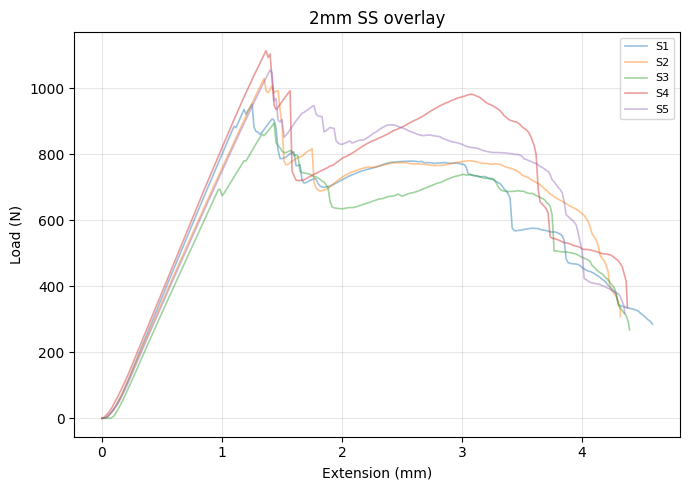

Saved overlay_2mm_LS.png


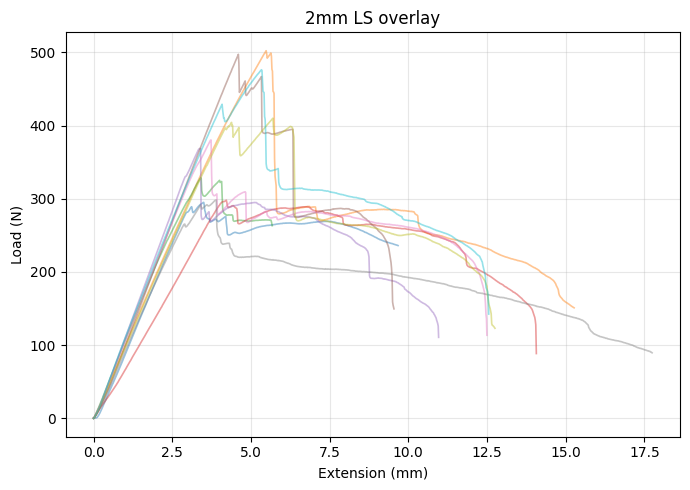

Saved overlay_3mm_SS.png


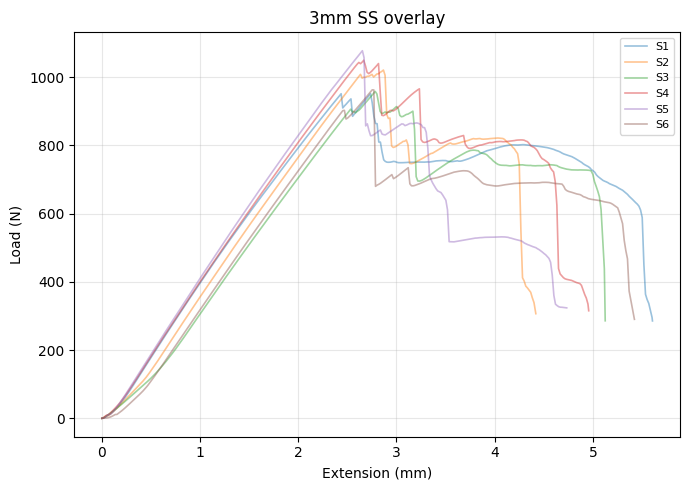

Saved overlay_3mm_LS.png


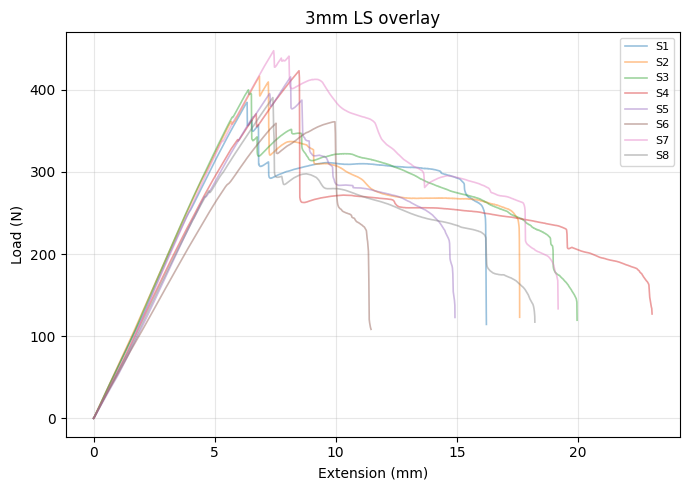

Saved overlay_4mm_SS.png


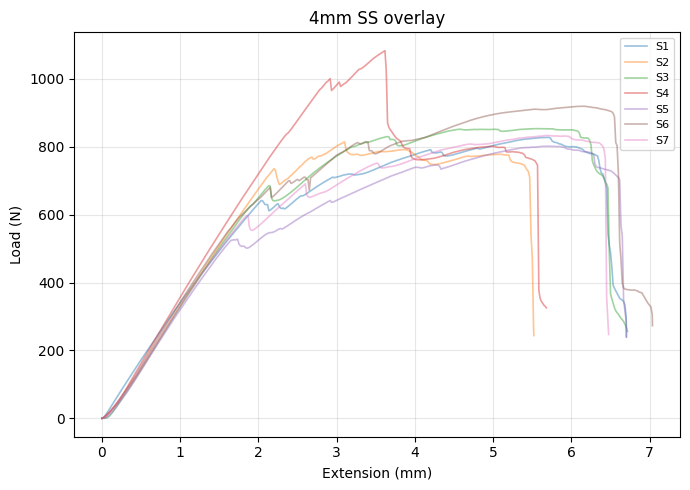

Saved overlay_4mm_LS.png


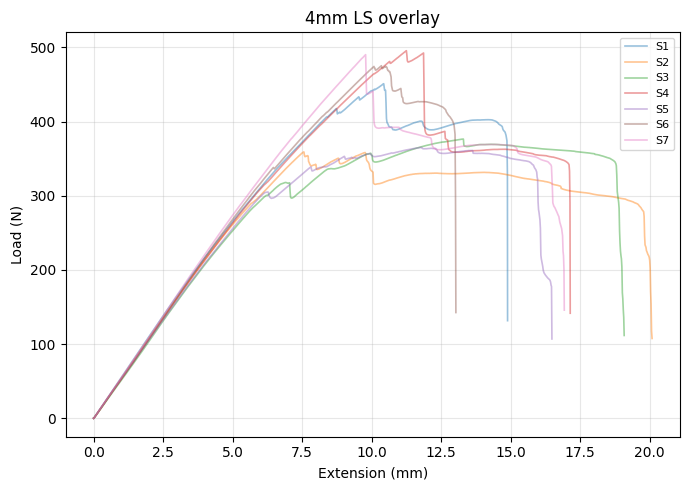

Saved overlay_6mm_SS.png


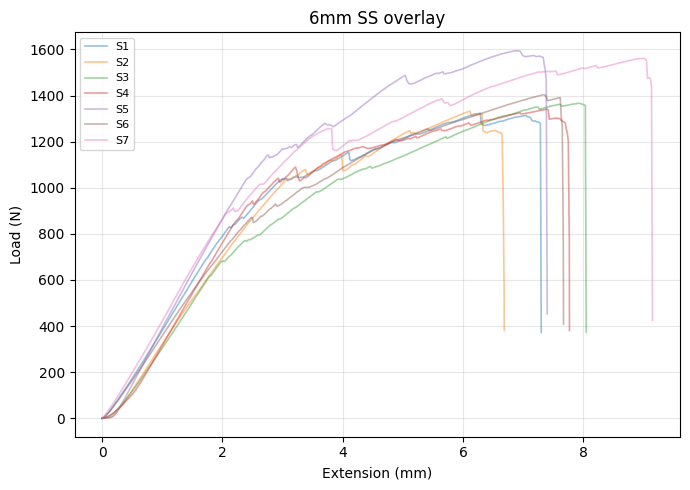

Saved overlay_6mm_LS.png


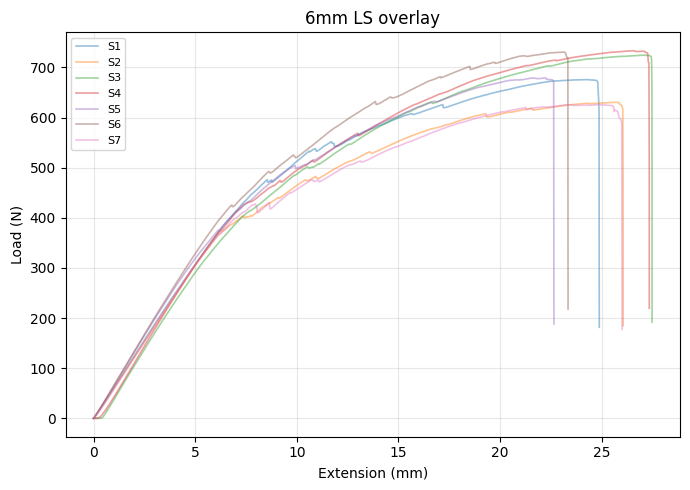

Saved overlay_8mm_SS.png


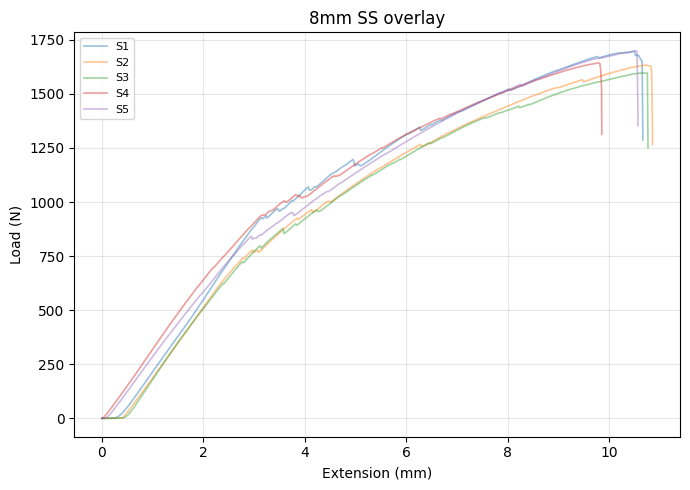

Saved overlay_8mm_LS.png


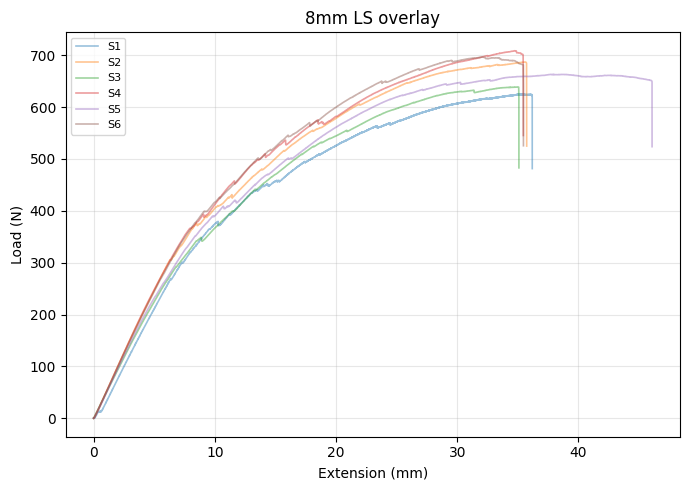

  plaque: SS=6 specimens, LS=7 specimens
Saved overlay_plaque_6mm_SS.png


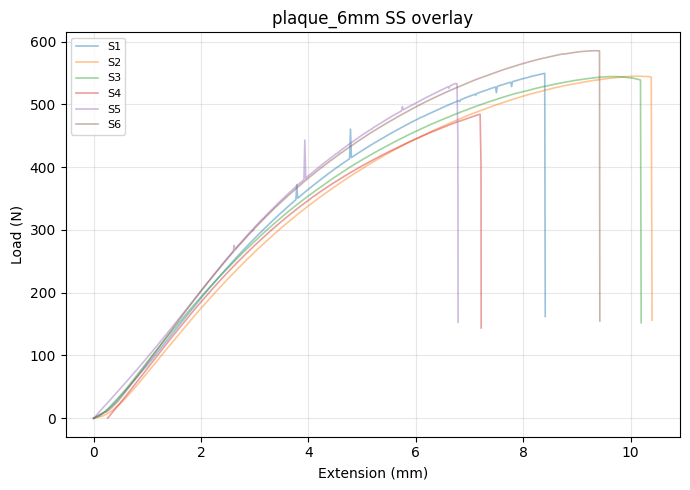

Saved overlay_plaque_6mm_LS.png


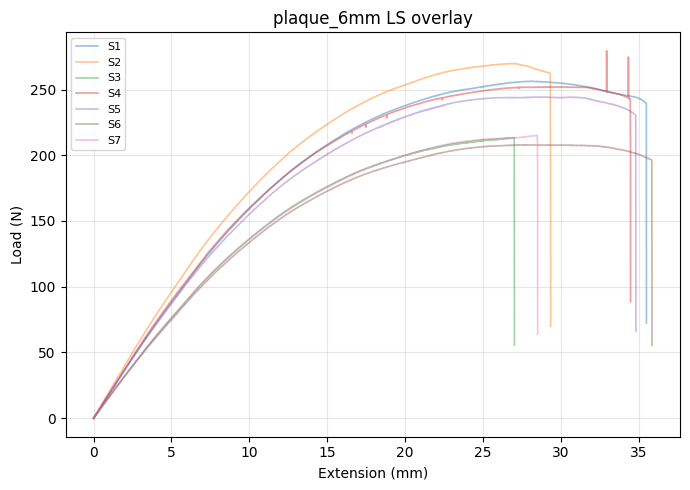

In [33]:
# Overlay plots per specimen group (thickness x span), with optional plaque overlays.

INCLUDE_PLAQUE_OVERLAYS = True


def plot_group_overlay(thickness: str, span: str, results: dict, save: bool = True) -> None:
    if not results:
        print(f"No data for {thickness} {span.upper()}.")
        return

    fig, ax = plt.subplots(figsize=(7, 5))
    for label in sorted(results.keys()):
        r = results[label]
        x = r["x_raw"]
        y = r["y_raw"]
        ax.plot(x, y, alpha=0.45, lw=1.2, label=label)

    span_label = "SS" if span == "ss" else "LS"
    ax.set_xlabel("Extension (mm)")
    ax.set_ylabel("Load (N)")
    ax.set_title(f"{thickness} {span_label} overlay")
    ax.grid(True, alpha=0.3)

    if len(results) <= 8:
        ax.legend(fontsize=8)

    plt.tight_layout()
    if save:
        fname = f"overlay_{thickness}_{span_label}.png"
        plt.savefig(fname, dpi=150)
        print(f"Saved {fname}")
    plt.show()


for thickness in THICKNESSES:
    for span in ("ss", "ls"):
        plot_group_overlay(thickness, span, all_results[thickness][span])

if INCLUDE_PLAQUE_OVERLAYS:
    plaque_ss_data, plaque_ls_data = load_plaque()
    plaque_ss = process_group(plaque_ss_data)
    plaque_ls = process_group(plaque_ls_data)
    plot_group_overlay("plaque_6mm", "ss", plaque_ss)
    plot_group_overlay("plaque_6mm", "ls", plaque_ls)


In [34]:
def _iqr_outliers(values: np.ndarray, fence: float = IQR_FENCE) -> np.ndarray:
    Q1, Q3 = np.percentile(values, 25), np.percentile(values, 75)
    iqr = Q3 - Q1
    lo, hi = Q1 - fence * iqr, Q3 + fence * iqr
    return (values < lo) | (values > hi)


per_specimen_rows = []

for thickness in THICKNESSES:
    span_dict = dim_group_df.set_index(["ThicknessLabel", "SpanType"])["span"].to_dict()
    for span in ("ss", "ls"):
        results = all_results[thickness][span]
        if not results:
            continue
        labels = list(results.keys())
        k_arr  = np.array([results[l]["slope"] for l in labels])
        out    = _iqr_outliers(k_arr) if len(k_arr) >= 4 else np.zeros_like(k_arr, dtype=bool)
        S = span_dict.get((thickness, span), np.nan)

        for l, k, is_out in zip(labels, k_arr, out):
            r = results[l]
            per_specimen_rows.append({
                "thickness":    thickness,
                "span":         span.upper(),
                "S (mm)":       S,
                "specimen":     l,
                "k (N/mm)":     round(float(k), 3),
                "F_lo (N)":     round(float(r["F_lo"]), 2),
                "F_hi (N)":     round(float(r["F_hi"]), 2),
                "R² fit":       round(float(r["r2_fit"]), 5),
                "peak (N)":     round(float(r["peak_load"]), 1),
                "outlier":      bool(is_out),
            })

per_specimen_df = pd.DataFrame(per_specimen_rows)
print(f"Per-specimen table: {len(per_specimen_df)} rows")
display(per_specimen_df)


Per-specimen table: 68 rows


,thickness,span,S (mm),specimen,k (N/mm),F_lo (N),F_hi (N),R² fit,peak (N),outlier
0,2mm,SS,25.0000,S1,863.4710,5.9600,926.9100,0.9996,952.0000,False
1,2mm,SS,25.0000,S2,810.5200,-0.9700,1039.2800,0.9998,1029.5000,False
2,2mm,SS,25.0000,S3,797.6250,-13.3100,704.6100,0.9998,894.5000,False
3,2mm,SS,25.0000,S4,861.9830,9.5600,1130.1900,0.9997,1113.3000,False
4,2mm,SS,25.0000,S5,803.0400,7.8800,1078.5900,0.9997,1055.1000,False
...,...,...,...,...,...,...,...,...,...,...
63,8mm,LS,200.0000,S2,49.1970,3.1000,311.4300,0.9993,686.8000,False
64,8mm,LS,200.0000,S3,43.3860,5.8800,301.6400,0.9982,638.7000,False
65,8mm,LS,200.0000,S4,47.6300,4.7000,370.6600,0.9980,708.6000,False
66,8mm,LS,200.0000,S5,47.3560,1.8700,242.6100,0.9991,662.9000,False


In [35]:
# ── LaTeX export: per-specimen k table for thesis appendix ─────────────────
# Generates a `longtable` matching the style of the dimensions table
# (Appendix C.2). Outliers are flagged with a dagger.
# Output is printed below and also saved to `specimen_k_table.tex`
# next to this notebook for easy copy-paste into the .tex source.

_THICK_LABEL = {
    "2mm":       r"2\,mm sandwich",
    "3mm":       r"3\,mm sandwich",
    "4mm":       r"4\,mm sandwich",
    "6mm":       r"6\,mm sandwich",
    "8mm":       r"8\,mm sandwich",
    "plaque_6mm": r"6\,mm plaque",
}
_SPAN_LABEL = {"SS": "short span", "LS": "long span"}


def _esc_underscores(name: str) -> str:
    return name.replace("_", r"\_")


def per_specimen_latex(df: pd.DataFrame, caption: str, label: str) -> str:
    out = [
        r"\begin{longtable}{lccc}",
        rf"\caption{{{caption}}}",
        rf"\label{{{label}}} \\",
        r"\toprule",
        r"Specimen & $k$ (N/mm) & Peak load (N) & $R^2$ \\",
        r"\midrule",
        r"\endfirsthead",
        "",
        r"\multicolumn{4}{c}{\textit{Table \thetable\ -- continued from previous page}} \\",
        r"\toprule",
        r"Specimen & $k$ (N/mm) & Peak load (N) & $R^2$ \\",
        r"\midrule",
        r"\endhead",
        "",
        r"\midrule",
        r"\multicolumn{4}{r}{\textit{Continued on next page}} \\",
        r"\endfoot",
        "",
        r"\bottomrule",
        r"\endlastfoot",
        "",
    ]

    # Preserve the order in which thicknesses appear in the dataframe
    thick_order = list(dict.fromkeys(df["thickness"].tolist()))

    for thickness in thick_order:
        for span in ("SS", "LS"):
            sub = df[(df["thickness"] == thickness) & (df["span"] == span)]
            if sub.empty:
                continue
            t_lbl = _THICK_LABEL.get(thickness, thickness)
            s_lbl = _SPAN_LABEL[span]
            out.append(rf"\multicolumn{{4}}{{l}}{{\textit{{{t_lbl} -- {s_lbl}}}}} \\")
            for _, row in sub.iterrows():
                name = _esc_underscores(str(row["specimen"]))
                mark = r"$^\dagger$" if bool(row["outlier"]) else ""
                k    = row["k (N/mm)"]
                pk   = row["peak (N)"]
                r2   = row["R² fit"]
                out.append(
                    rf"\texttt{{{name}}}{mark} & {k:.2f} & {pk:.1f} & {r2:.4f} \\"
                )
            out.append(r"\addlinespace")

    if out and out[-1] == r"\addlinespace":
        out.pop()

    out.append(r"\end{longtable}")
    return "\n".join(out)


_caption = (
    r"Per-specimen flexural stiffness $k$ from linear-region fits "
    r"($R^2 \geq " + f"{R2_THRESHOLD}" + r"$, window " + f"{WINDOW_SIZE}"
    r" samples), with peak load and fit quality. Specimens flagged "
    r"$^\dagger$ were rejected as IQR outliers (fence "
    + f"{IQR_FENCE}" + r"$\times$IQR) before group means were computed."
)

_latex = per_specimen_latex(
    per_specimen_df,
    caption=_caption,
    label="tab:specimen-k",
)

_out_file = Path.cwd() / "specimen_k_table.tex"
_out_file.write_text(_latex)
print(_latex)
print(f"\n--- saved to {_out_file} ---")


\begin{longtable}{lccc}
\caption{Per-specimen flexural stiffness $k$ from linear-region fits ($R^2 \geq 0.998$, window 30 samples), with peak load and fit quality. Specimens flagged $^\dagger$ were rejected as IQR outliers (fence 1.5$\times$IQR) before group means were computed.}
\label{tab:specimen-k} \\
\toprule
Specimen & $k$ (N/mm) & Peak load (N) & $R^2$ \\
\midrule
\endfirsthead

\multicolumn{4}{c}{\textit{Table \thetable\ -- continued from previous page}} \\
\toprule
Specimen & $k$ (N/mm) & Peak load (N) & $R^2$ \\
\midrule
\endhead

\midrule
\multicolumn{4}{r}{\textit{Continued on next page}} \\
\endfoot

\bottomrule
\endlastfoot

\multicolumn{4}{l}{\textit{2\,mm sandwich -- short span}} \\
\texttt{S1} & 863.47 & 952.0 & 0.9996 \\
\texttt{S2} & 810.52 & 1029.5 & 0.9998 \\
\texttt{S3} & 797.62 & 894.5 & 0.9998 \\
\texttt{S4} & 861.98 & 1113.3 & 0.9997 \\
\texttt{S5} & 803.04 & 1055.1 & 0.9997 \\
\addlinespace
\multicolumn{4}{l}{\textit{2\,mm sandwich -- long span}} \\
\texttt{S1

## 7. Group-mean `k`, IQR-screened — group summary (Table 2)

In [36]:
group_summary_rows = []

for thickness in THICKNESSES:
    dim_t = dim_thickness_df[dim_thickness_df["ThicknessLabel"] == thickness]
    if dim_t.empty:
        continue
    d_mean = float(dim_t["d_mean"].iloc[0])
    d_std  = float(dim_t["d_std"].iloc[0])
    c_mean = d_mean - 2 * FACE_THICKNESS

    span_lookup = dim_group_df.set_index(["ThicknessLabel", "SpanType"])["span"].to_dict()
    S1 = span_lookup.get((thickness, "ss"), np.nan)
    S2 = span_lookup.get((thickness, "ls"), np.nan)

    sub = per_specimen_df[per_specimen_df["thickness"] == thickness]

    def stats_for(sp):
        s = sub[(sub["span"] == sp.upper()) & (~sub["outlier"])]
        s_all = sub[sub["span"] == sp.upper()]
        if s.empty:
            return np.nan, np.nan, np.nan, 0, 0
        k_mean = float(s["k (N/mm)"].mean())
        k_std  = float(s["k (N/mm)"].std(ddof=1)) if len(s) > 1 else 0.0
        cv     = (k_std / k_mean * 100) if k_mean > 0 else np.nan
        n_used = int(len(s))
        n_rej  = int(len(s_all) - n_used)
        return k_mean, k_std, cv, n_used, n_rej

    k_ss, sd_ss, cv_ss, n_ss, nr_ss = stats_for("ss")
    k_ls, sd_ls, cv_ls, n_ls, nr_ls = stats_for("ls")
    ratio = (k_ss / k_ls) if (k_ls and not np.isnan(k_ls) and k_ls > 0) else np.nan

    group_summary_rows.append({
        "thickness":        thickness,
        "d_mean (mm)":      round(d_mean, 3),
        "d_std (mm)":       round(d_std, 3),
        "c (mm)":           round(c_mean, 3),
        "k_SS (N/mm)":      round(k_ss, 2)  if not np.isnan(k_ss) else np.nan,
        "k_SS_SD":          round(sd_ss, 2) if not np.isnan(sd_ss) else np.nan,
        "CV_SS (%)":        round(cv_ss, 2) if not np.isnan(cv_ss) else np.nan,
        "n_SS used/rej":    f"{n_ss}/{nr_ss}",
        "k_LS (N/mm)":      round(k_ls, 2)  if not np.isnan(k_ls) else np.nan,
        "k_LS_SD":          round(sd_ls, 2) if not np.isnan(sd_ls) else np.nan,
        "CV_LS (%)":        round(cv_ls, 2) if not np.isnan(cv_ls) else np.nan,
        "n_LS used/rej":    f"{n_ls}/{nr_ls}",
        "k_SS/k_LS":        round(ratio, 3) if not np.isnan(ratio) else np.nan,
        "S1 (mm)":          S1,
        "S2 (mm)":          S2,
    })

group_summary_df = pd.DataFrame(group_summary_rows)
print("Group summary table:")
display(group_summary_df)


Group summary table:


,thickness,d_mean (mm),d_std (mm),c (mm),k_SS (N/mm),k_SS_SD,CV_SS (%),n_SS used/rej,k_LS (N/mm),k_LS_SD,CV_LS (%),n_LS used/rej,k_SS/k_LS,S1 (mm),S2 (mm)
0,2mm,2.0240,0.0270,0.5840,827.3300,32.6400,3.9500,5/0,103.2900,7.7500,7.5000,9/1,8.0100,25.0000,50.0000
1,3mm,2.5760,0.0610,1.1360,409.2700,2.6100,0.6400,4/2,60.1900,4.5100,7.4900,8/0,6.8000,37.5000,75.0000
2,4mm,3.4680,0.0780,2.0280,352.1100,10.3600,2.9400,6/1,51.0000,1.3500,2.6400,7/0,6.9040,50.0000,100.0000
3,6mm,6.1090,0.0750,4.6690,412.0300,42.9600,10.4300,7/0,61.8800,2.0600,3.3400,7/0,6.6580,75.0000,150.0000
4,8mm,7.3160,0.0250,5.8760,317.8200,14.8700,4.6800,5/0,46.7400,2.1700,4.6400,5/1,6.8000,100.0000,200.0000


## 8. Plot 1 — Group-mean `k` vs measured `d`

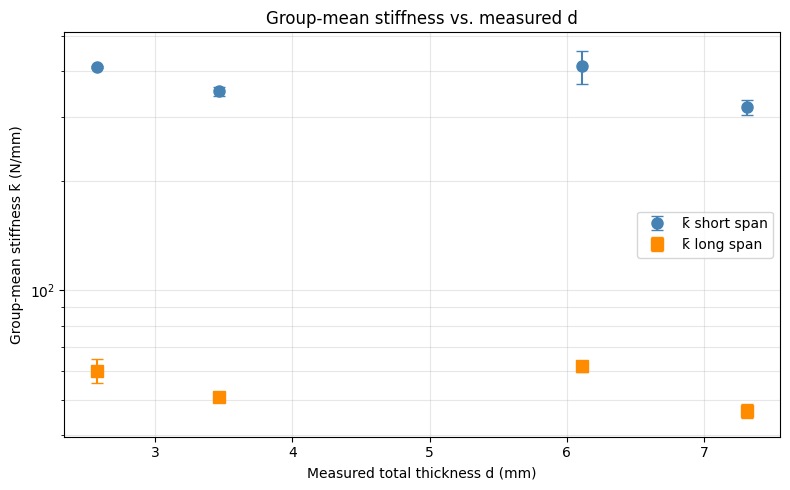

In [37]:
def _plot_mask(df: pd.DataFrame) -> np.ndarray:
    return ~df["thickness"].isin(EXCLUDE_FROM_PLOTS)


fig, ax = plt.subplots(figsize=(8, 5))
m = _plot_mask(group_summary_df)
gp = group_summary_df[m].sort_values("d_mean (mm)")

ax.errorbar(gp["d_mean (mm)"], gp["k_SS (N/mm)"], yerr=gp["k_SS_SD"],
            fmt="o", color="steelblue", ms=8, capsize=4, label="k̄ short span")
ax.errorbar(gp["d_mean (mm)"], gp["k_LS (N/mm)"], yerr=gp["k_LS_SD"],
            fmt="s", color="darkorange", ms=8, capsize=4, label="k̄ long span")

ax.set_xlabel("Measured total thickness d (mm)")
ax.set_ylabel("Group-mean stiffness k̄ (N/mm)")
ax.set_title("Group-mean stiffness vs. measured d")
ax.set_yscale("log")
ax.grid(True, alpha=0.3, which="both")
ax.legend()
plt.tight_layout()
plt.savefig("fig1_k_vs_d.png", dpi=150)
plt.show()


## 9. ASTM D7250 inversion (k-form) and `G`

Substituting `Δ₁ = P/k̄_SS`, `Δ₂ = P/k̄_LS` (with `P₁ = P₂ = P`) into ASTM D7250 Eqs. (5)–(6), `P` cancels identically and the inversion reduces to closed-form expressions in the two group-mean stiffnesses and the span lengths alone:

```
        k̄_SS · S1³ · (1 − S2²/S1²)
D  =  ───────────────────────────────────────
            48 [ 1 − S1 · k̄_SS / (S2 · k̄_LS) ]


        k̄_SS · S1 · (S1²/S2² − 1)
U  =  ───────────────────────────────────────
            4  [ S1³ · k̄_SS / (S2³ · k̄_LS) − 1 ]


        U · (d − 2t)
G  =  ───────────────
        (d − t)² · b
```

These collapse the per-load-level evaluation in the standard to one closed-form pair per thickness. The code below evaluates the equivalent form `D = numerator / [48 · (1/k̄_SS) · bracket]` (and likewise for U) — algebraically identical, kept in this layout in the implementation as a transparent record of the substitution path.


In [38]:
def D_and_U_from_k(k_ss: float, k_ls: float, S1: float, S2: float) -> tuple:
    """Closed-form ASTM D7250 inversion (P cancels under Δ = P/k)."""
    if any(np.isnan([k_ss, k_ls, S1, S2])) or k_ss == 0 or k_ls == 0:
        return np.nan, np.nan
    num_D = S1**3 * (1.0 - (S2**2 / S1**2))
    den_D = 48.0 * (1.0 / k_ss) * (1.0 - (k_ss * S1) / (k_ls * S2))
    D = num_D / den_D

    num_U = S1 * (S1**2 / S2**2 - 1.0)
    den_U = 4.0 * (1.0 / k_ss) * (((k_ss * S1**3) / (k_ls * S2**3)) - 1.0)
    U = num_U / den_U
    return D, U


def G_from_U(U: float, d: float, b: float, t: float = FACE_THICKNESS) -> float:
    if any(np.isnan([U, d, b])) or (d - t) <= 0:
        return np.nan
    return U * (d - 2 * t) / ((d - t) ** 2 * b)


derived_rows = []
for _, row in group_summary_df.iterrows():
    thickness = row["thickness"]
    dim_t = dim_thickness_df[dim_thickness_df["ThicknessLabel"] == thickness]
    if dim_t.empty:
        continue
    d = float(dim_t["d_mean"].iloc[0])
    b = float(dim_t["b_mean"].iloc[0])
    t = FACE_THICKNESS
    c = d - 2 * t

    S1, S2 = row["S1 (mm)"], row["S2 (mm)"]
    k_ss, k_ls = row["k_SS (N/mm)"], row["k_LS (N/mm)"]

    D, U = D_and_U_from_k(k_ss, k_ls, S1, S2)
    G = G_from_U(U, d, b, t)

    # Validity flags per ASTM D7250 Note 3 and physical sanity
    valid_tc = (t / c) < 0.10 if c > 0 else False
    valid_sd = (S1 / d) > 20  if d > 0 else False
    physical = (D is not None) and (U is not None) and (D > 0) and (U > 0) and (G > 0)

    derived_rows.append({
        "thickness":  thickness,
        "d (mm)":     round(d, 3),
        "b (mm)":     round(b, 3),
        "c (mm)":     round(c, 3),
        "t/c":        round(t / c, 3) if c > 0 else np.nan,
        "S1/d":       round(S1 / d, 1) if d > 0 else np.nan,
        "D (N·mm²)":  round(D, 1) if not np.isnan(D) else np.nan,
        "U (N)":      round(U, 1) if not np.isnan(U) else np.nan,
        "G (MPa)":    round(G, 2) if not np.isnan(G) else np.nan,
        "physical":   physical,
        "t/c<0.1":    valid_tc,
        "S1/d>20":    valid_sd,
    })

derived_df = pd.DataFrame(derived_rows)
print("Derived properties (Table 3):")
display(derived_df)


Derived properties (Table 3):


,thickness,d (mm),b (mm),c (mm),t/c,S1/d,D (N·mm²),U (N),G (MPa),physical,t/c<0.1,S1/d>20
0,2mm,2.0240,15.9670,0.5840,1.2330,12.4000,268875.0000,-3172831.0000,-68245.2200,False,False,False
1,3mm,2.5760,16.3790,1.1360,0.6340,14.6000,562089.6000,19178.7000,386.1600,True,False,False
2,4mm,3.4680,16.6100,2.0280,0.3550,14.4000,1121857.0000,24097.7000,389.6300,True,False,False
3,6mm,6.1090,15.9490,4.6690,0.1540,12.3000,4664160.6000,34554.2000,348.3000,True,False,False
4,8mm,7.3160,16.0380,5.8760,0.1230,13.7000,8277005.2000,39719.0000,334.4600,True,False,False


## 10. Plot 2 — `D` vs `d` with classical predictions

Two predictions on the same axis:

- Thin-face: `D = ½ E_f · b · t · d²`
- Full sandwich: `D = E_f · b · (d³ − c³) / 12`, with `c = d − 2t`

Both evaluated with `E_f = 20 GPa` (ROM, Section 2). Measured points overlaid with error bars (uncertainty propagated from group `k` SD).


In [39]:
def D_thin_face(E_f_GPa, b_mm, t_mm, d_mm):
    """D in N·mm² with E_f in GPa, lengths in mm."""
    E_f_MPa = E_f_GPa * 1000.0
    return 0.5 * E_f_MPa * b_mm * t_mm * d_mm**2

def D_full_sandwich(E_f_GPa, b_mm, t_mm, d_mm):
    E_f_MPa = E_f_GPa * 1000.0
    c = d_mm - 2 * t_mm
    return E_f_MPa * b_mm * (d_mm**3 - c**3) / 12.0


def D_err_from_k(k_ss, sd_ss, k_ls, sd_ls, S1, S2):
    """Propagate group-k SDs into a 1σ uncertainty on D via finite differences."""
    if any(np.isnan([k_ss, k_ls, sd_ss, sd_ls])):
        return np.nan
    base, _ = D_and_U_from_k(k_ss, k_ls, S1, S2)
    if np.isnan(base):
        return np.nan
    h_ss, h_ls = max(1e-6, sd_ss), max(1e-6, sd_ls)
    dD_dkss = (D_and_U_from_k(k_ss + h_ss, k_ls, S1, S2)[0]
               - D_and_U_from_k(k_ss - h_ss, k_ls, S1, S2)[0]) / (2 * h_ss)
    dD_dkls = (D_and_U_from_k(k_ss, k_ls + h_ls, S1, S2)[0]
               - D_and_U_from_k(k_ss, k_ls - h_ls, S1, S2)[0]) / (2 * h_ls)
    return float(np.sqrt((dD_dkss * sd_ss)**2 + (dD_dkls * sd_ls)**2))


# attach error bars to derived_df
err_D = []
for _, row in group_summary_df.iterrows():
    thickness = row["thickness"]
    if thickness not in derived_df["thickness"].values:
        err_D.append(np.nan)
        continue
    e = D_err_from_k(row["k_SS (N/mm)"], row["k_SS_SD"],
                     row["k_LS (N/mm)"], row["k_LS_SD"],
                     row["S1 (mm)"],     row["S2 (mm)"])
    err_D.append(e)
derived_df["D_err (N·mm²)"] = err_D
display(derived_df)


,thickness,d (mm),b (mm),c (mm),t/c,S1/d,D (N·mm²),U (N),G (MPa),physical,t/c<0.1,S1/d>20,D_err (N·mm²)
0,2mm,2.0240,15.9670,0.5840,1.2330,12.4000,268875.0000,-3172831.0000,-68245.2200,False,False,False,27136.4916
1,3mm,2.5760,16.3790,1.1360,0.6340,14.6000,562089.6000,19178.7000,386.1600,True,False,False,59744.0346
2,4mm,3.4680,16.6100,2.0280,0.3550,14.4000,1121857.0000,24097.7000,389.6300,True,False,False,43932.4333
3,6mm,6.1090,15.9490,4.6690,0.1540,12.3000,4664160.6000,34554.2000,348.3000,True,False,False,308002.9149
4,8mm,7.3160,16.0380,5.8760,0.1230,13.7000,8277005.2000,39719.0000,334.4600,True,False,False,568211.1081


Reference width for prediction lines: b̄ = 16.24 mm


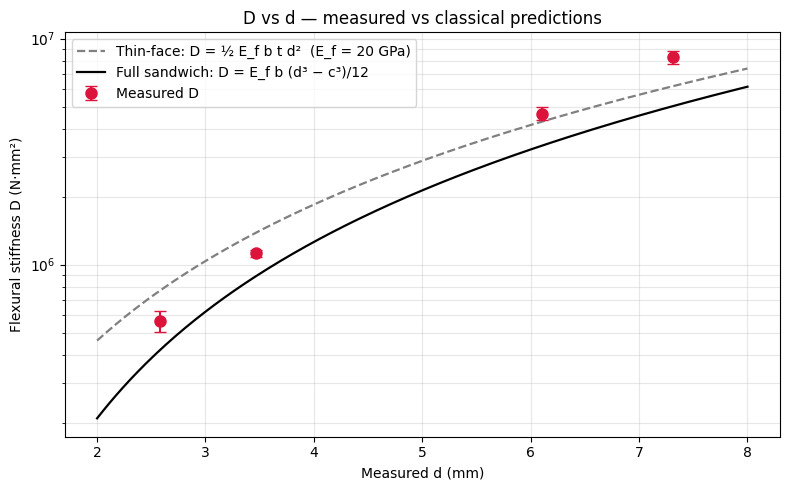

In [40]:
# Use a representative b for the prediction lines (mean across thicknesses we plot)
plot_mask = ~derived_df["thickness"].isin(EXCLUDE_FROM_PLOTS) & derived_df["physical"]
b_ref = float(derived_df.loc[plot_mask, "b (mm)"].mean())
print(f"Reference width for prediction lines: b̄ = {b_ref:.2f} mm")

d_grid = np.linspace(2.0, 8.0, 200)
D_thin = D_thin_face(E_FACE_THEORY_GPA, b_ref, FACE_THICKNESS, d_grid)
D_full = D_full_sandwich(E_FACE_THEORY_GPA, b_ref, FACE_THICKNESS, d_grid)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(d_grid, D_thin, "--", color="grey", lw=1.6,
        label=f"Thin-face: D = ½ E_f b t d²  (E_f = {E_FACE_THEORY_GPA:.0f} GPa)")
ax.plot(d_grid, D_full, "-",  color="black", lw=1.6,
        label=f"Full sandwich: D = E_f b (d³ − c³)/12")

dp = derived_df[plot_mask].sort_values("d (mm)")
ax.errorbar(dp["d (mm)"], dp["D (N·mm²)"], yerr=dp["D_err (N·mm²)"],
            fmt="o", color="crimson", ms=8, capsize=4, label="Measured D")

ax.set_xlabel("Measured d (mm)")
ax.set_ylabel("Flexural stiffness D (N·mm²)")
ax.set_title("D vs d — measured vs classical predictions")
ax.set_yscale("log")
ax.grid(True, alpha=0.3, which="both")
ax.legend()
plt.tight_layout()
plt.savefig("fig2_D_vs_d.png", dpi=150)
plt.show()


## 11. Back-calculated `E_face` per thickness (Table 4)

Invert the full-sandwich expression:

```
E_face = 12 D / [ b (d³ − c³) ]   with c = d − 2t,  E_face in MPa, then convert to GPa.
```


In [41]:
def E_face_back(D_Nmm2, b_mm, t_mm, d_mm):
    c = d_mm - 2 * t_mm
    if D_Nmm2 is None or np.isnan(D_Nmm2) or (d_mm**3 - c**3) <= 0:
        return np.nan
    E_MPa = 12.0 * D_Nmm2 / (b_mm * (d_mm**3 - c**3))
    return E_MPa / 1000.0   # → GPa


eface_rows = []
for _, row in derived_df.iterrows():
    E = E_face_back(row["D (N·mm²)"], row["b (mm)"], FACE_THICKNESS, row["d (mm)"])
    eface_rows.append({
        "thickness":     row["thickness"],
        "d (mm)":        row["d (mm)"],
        "E_face (GPa)":  round(E, 2) if not np.isnan(E) else np.nan,
        "physical":      row["physical"],
    })
eface_df = pd.DataFrame(eface_rows)
print("Back-calculated E_face (Table 4):")
display(eface_df)


Back-calculated E_face (Table 4):


,thickness,d (mm),E_face (GPa),physical
0,2mm,2.0240,24.9700,False
1,3mm,2.5760,26.3500,True
2,4mm,3.4680,24.2900,True
3,6mm,6.1090,27.8100,True
4,8mm,7.3160,32.8200,True


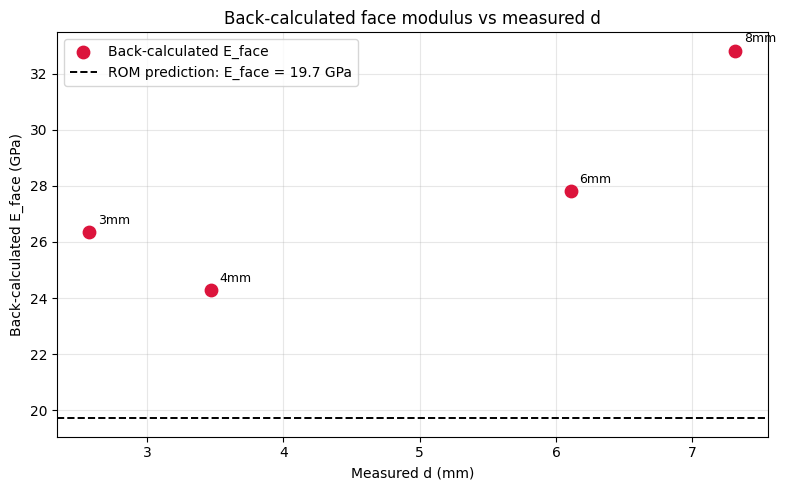

In [42]:
fig, ax = plt.subplots(figsize=(8, 5))
mp = ~eface_df["thickness"].isin(EXCLUDE_FROM_PLOTS) & eface_df["physical"]
ep = eface_df[mp].sort_values("d (mm)")

ax.scatter(ep["d (mm)"], ep["E_face (GPa)"], color="crimson", s=80, zorder=3,
           label="Back-calculated E_face")
ax.axhline(E_FACE_THEORY_GPA, ls="--", color="black", lw=1.4,
           label=f"ROM prediction: E_face = {E_FACE_THEORY_GPA:.1f} GPa")

# annotate each point with thickness
for _, r in ep.iterrows():
    ax.annotate(r["thickness"], (r["d (mm)"], r["E_face (GPa)"]),
                xytext=(6, 6), textcoords="offset points", fontsize=9)

ax.set_xlabel("Measured d (mm)")
ax.set_ylabel("Back-calculated E_face (GPa)")
ax.set_title("Back-calculated face modulus vs measured d")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig("fig5_Eface_vs_d.png", dpi=150)
plt.show()


## 12. Plot 3 — `U` vs `d`

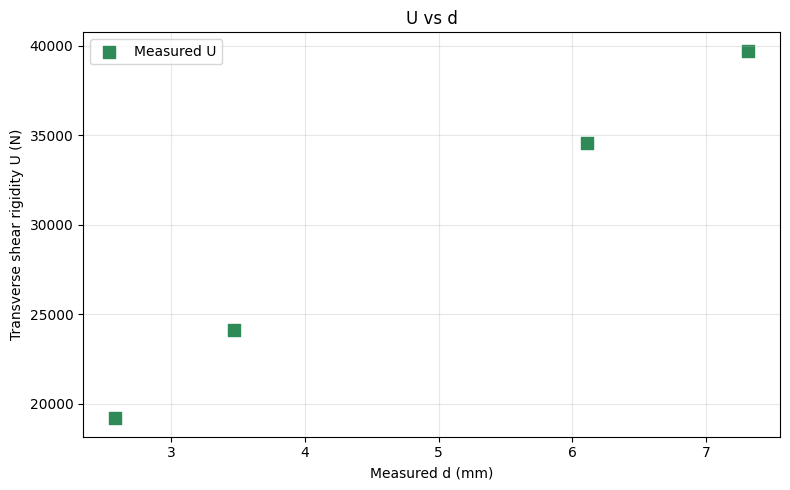

In [43]:
def U_err_from_k(k_ss, sd_ss, k_ls, sd_ls, S1, S2):
    if any(np.isnan([k_ss, k_ls, sd_ss, sd_ls])):
        return np.nan
    h_ss, h_ls = max(1e-6, sd_ss), max(1e-6, sd_ls)
    dU_dkss = (D_and_U_from_k(k_ss + h_ss, k_ls, S1, S2)[1]
               - D_and_U_from_k(k_ss - h_ss, k_ls, S1, S2)[1]) / (2 * h_ss)
    dU_dkls = (D_and_U_from_k(k_ss, k_ls + h_ls, S1, S2)[1]
               - D_and_U_from_k(k_ss, k_ls - h_ls, S1, S2)[1]) / (2 * h_ls)
    return float(np.sqrt((dU_dkss * sd_ss)**2 + (dU_dkls * sd_ls)**2))


u_err = []
for _, row in group_summary_df.iterrows():
    if row["thickness"] not in derived_df["thickness"].values:
        u_err.append(np.nan); continue
    u_err.append(U_err_from_k(row["k_SS (N/mm)"], row["k_SS_SD"],
                              row["k_LS (N/mm)"], row["k_LS_SD"],
                              row["S1 (mm)"],     row["S2 (mm)"]))
derived_df["U_err (N)"] = u_err

fig, ax = plt.subplots(figsize=(8, 5))
mp = ~derived_df["thickness"].isin(EXCLUDE_FROM_PLOTS) & derived_df["physical"]
dp = derived_df[mp].sort_values("d (mm)")

ax.scatter(dp["d (mm)"], dp["U (N)"], color="seagreen", s=80, marker="s",
           label="Measured U")
ax.set_xlabel("Measured d (mm)")
ax.set_ylabel("Transverse shear rigidity U (N)")
ax.set_title("U vs d")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig("fig3_U_vs_d.png", dpi=150)
plt.show()


## 13. Plot 4 — `G` vs `d` with mean ± SD band across valid thicknesses

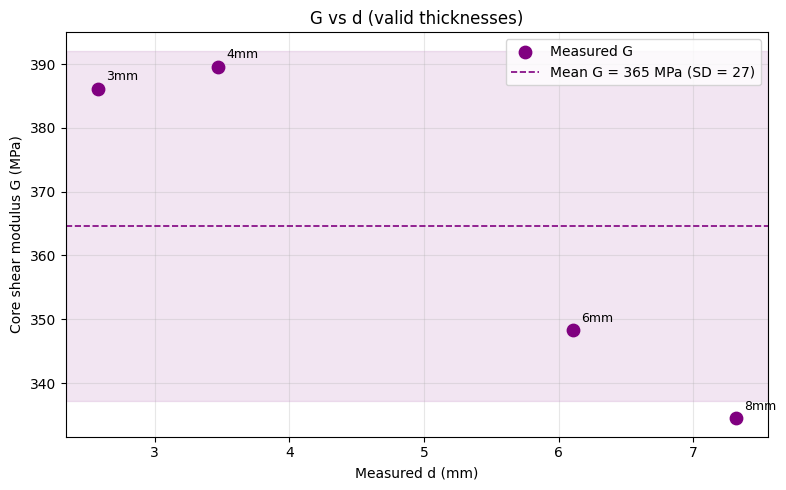

In [44]:
fig, ax = plt.subplots(figsize=(8, 5))
mp = ~derived_df["thickness"].isin(EXCLUDE_FROM_PLOTS) & derived_df["physical"]
dp = derived_df[mp].sort_values("d (mm)")

ax.scatter(dp["d (mm)"], dp["G (MPa)"], color="purple", s=80, zorder=3, label="Measured G")
for _, r in dp.iterrows():
    ax.annotate(r["thickness"], (r["d (mm)"], r["G (MPa)"]),
                xytext=(6, 6), textcoords="offset points", fontsize=9)

if len(dp) >= 2:
    g_mean = dp["G (MPa)"].mean()
    g_sd   = dp["G (MPa)"].std(ddof=1)
    ax.axhline(g_mean, color="purple", ls="--", lw=1.2,
               label=f"Mean G = {g_mean:.0f} MPa (SD = {g_sd:.0f})")
    ax.axhspan(g_mean - g_sd, g_mean + g_sd, color="purple", alpha=0.10)

ax.set_xlabel("Measured d (mm)")
ax.set_ylabel("Core shear modulus G (MPa)")
ax.set_title("G vs d (valid thicknesses)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig("fig4_G_vs_d.png", dpi=150)
plt.show()


## 14. 6 mm pellet-only plaque (monolithic Euler–Bernoulli)

The plaque is **not** processed as a sandwich (with `t = 0` the ASTM D7250 inversion is degenerate). It is processed as a homogeneous beam:

```
E = k S³ / (48 I),   I = b d³ / 12
```

evaluated at the short and long span independently. The two `E` values are not expected to agree if the plaque is shear-sensitive — that's the diagnostic.


In [45]:
plaque_ss_data, plaque_ls_data = load_plaque()
plaque_ss = process_group(plaque_ss_data)
plaque_ls = process_group(plaque_ls_data)

# Plaque dims (from dimension book row group "plaque_6mm")
plaque_dim = dim_df[dim_df["ThicknessLabel"] == "plaque_6mm"]
print(f"Plaque dimension rows: {len(plaque_dim)}")

def plaque_summary(results: dict, span_label: str, dim_subset: pd.DataFrame) -> dict:
    if not results:
        return {}
    labels = list(results.keys())
    k_arr  = np.array([results[l]["slope"] for l in labels])
    out    = _iqr_outliers(k_arr) if len(k_arr) >= 4 else np.zeros_like(k_arr, dtype=bool)
    k_clean = k_arr[~out]
    k_mean  = float(np.mean(k_clean))
    k_sd    = float(np.std(k_clean, ddof=1)) if len(k_clean) > 1 else 0.0

    sub = dim_subset[dim_subset["SpanType"] == span_label.lower()]
    b_mean = float(sub["Width (Average)"].mean())     if not sub.empty else np.nan
    d_mean = float(sub["Thickness (Average)"].mean()) if not sub.empty else np.nan
    S      = float(sub["Span Length (nominal)"].mean()) if not sub.empty else np.nan

    return {
        "span":  span_label.upper(),
        "S":     S,
        "b":     b_mean,
        "d":     d_mean,
        "k":     k_mean,
        "k_sd":  k_sd,
        "n":     int((~out).sum()),
        "n_rej": int(out.sum()),
    }

ps_ss = plaque_summary(plaque_ss, "ss", plaque_dim)
ps_ls = plaque_summary(plaque_ls, "ls", plaque_dim)


def E_monolithic(k_Nmm, S_mm, b_mm, d_mm):
    """E in MPa from k S³ / (48 I)."""
    if any(np.isnan([k_Nmm, S_mm, b_mm, d_mm])) or d_mm <= 0:
        return np.nan
    I = b_mm * d_mm**3 / 12.0
    return k_Nmm * S_mm**3 / (48.0 * I)


plaque_rows = []
for ps in (ps_ss, ps_ls):
    if not ps:
        continue
    E_MPa = E_monolithic(ps["k"], ps["S"], ps["b"], ps["d"])
    plaque_rows.append({
        "span":         ps["span"],
        "S (mm)":       round(ps["S"], 1),
        "b (mm)":       round(ps["b"], 2),
        "d (mm)":       round(ps["d"], 2),
        "k (N/mm)":     round(ps["k"], 2),
        "k_SD":         round(ps["k_sd"], 2),
        "n used/rej":   f"{ps['n']}/{ps['n_rej']}",
        "E (GPa)":      round(E_MPa / 1000.0, 2) if not np.isnan(E_MPa) else np.nan,
    })

plaque_df = pd.DataFrame(plaque_rows)
print("\nPlaque (monolithic Euler-Bernoulli) — Table 5:")
display(plaque_df)


  plaque: SS=6 specimens, LS=7 specimens
Plaque dimension rows: 13

Plaque (monolithic Euler-Bernoulli) — Table 5:


,span,S (mm),b (mm),d (mm),k (N/mm),k_SD,n used/rej,E (GPa)
0,SS,75.0000,16.0800,5.9700,77.4800,18.5200,6/0,2.3900
1,LS,150.0000,16.3100,6.0000,15.6200,2.9400,7/0,3.7300


In [46]:
# Compare plaque to 6 mm sandwich. The plaque has no face sheets, so we compute
# its EI as I = b·d³/12 with E from the long-span (bending-dominated) result.
six_mm = derived_df[derived_df["thickness"] == "6mm"]

if not six_mm.empty and not plaque_df.empty:
    D_sandwich = float(six_mm["D (N·mm²)"].iloc[0])
    # Use the long-span E (the one less contaminated by shear) for the plaque EI
    ls_row = plaque_df[plaque_df["span"] == "LS"]
    ss_row = plaque_df[plaque_df["span"] == "SS"]

    plaque_compare_rows = []
    if not ls_row.empty:
        E_ls = float(ls_row["E (GPa)"].iloc[0]) * 1000.0  # MPa
        b_ls = float(ls_row["b (mm)"].iloc[0])
        d_ls = float(ls_row["d (mm)"].iloc[0])
        EI_ls = E_ls * b_ls * d_ls**3 / 12.0
        plaque_compare_rows.append({
            "specimen":     "6 mm plaque (LS-derived)",
            "EI (N·mm²)":   round(EI_ls, 1),
            "ratio to sandwich": round(D_sandwich / EI_ls, 2),
        })
    if not ss_row.empty:
        E_ss = float(ss_row["E (GPa)"].iloc[0]) * 1000.0
        b_ss = float(ss_row["b (mm)"].iloc[0])
        d_ss = float(ss_row["d (mm)"].iloc[0])
        EI_ss = E_ss * b_ss * d_ss**3 / 12.0
        plaque_compare_rows.append({
            "specimen":     "6 mm plaque (SS-derived)",
            "EI (N·mm²)":   round(EI_ss, 1),
            "ratio to sandwich": round(D_sandwich / EI_ss, 2),
        })
    plaque_compare_rows.append({
        "specimen":     "6 mm sandwich",
        "EI (N·mm²)":   round(D_sandwich, 1),
        "ratio to sandwich": 1.00,
    })
    compare_df = pd.DataFrame(plaque_compare_rows)
    print("Plaque vs 6 mm sandwich:")
    display(compare_df)
else:
    print("Need both 6 mm sandwich and plaque data to compare.")


Plaque vs 6 mm sandwich:


,specimen,EI (N·mm²),ratio to sandwich
0,6 mm plaque (LS-derived),1095053.4000,4.2600
1,6 mm plaque (SS-derived),681437.0000,6.8400
2,6 mm sandwich,4664160.6000,1.0000


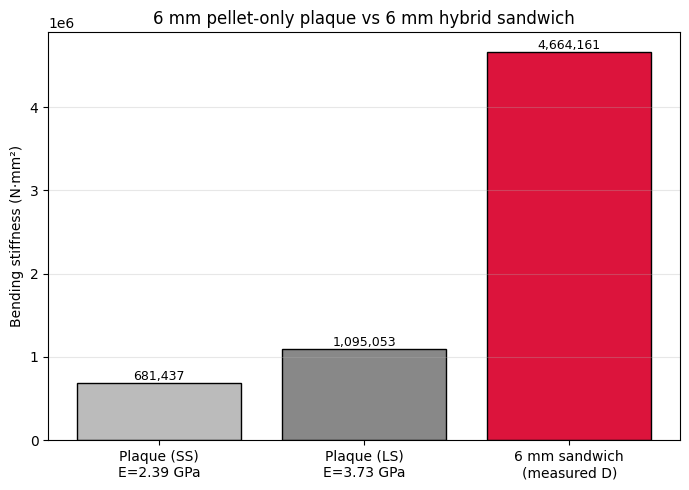

In [47]:
# Side-by-side bar of EI (plaque LS-derived) vs D (sandwich)
fig, ax = plt.subplots(figsize=(7, 5))
labels = []
values = []

if not plaque_df.empty:
    for _, r in plaque_df.iterrows():
        E_MPa = float(r["E (GPa)"]) * 1000.0
        b = float(r["b (mm)"]); d = float(r["d (mm)"])
        EI = E_MPa * b * d**3 / 12.0
        labels.append(f"Plaque ({r['span']})\nE={r['E (GPa)']} GPa")
        values.append(EI)

if not six_mm.empty:
    labels.append("6 mm sandwich\n(measured D)")
    values.append(float(six_mm["D (N·mm²)"].iloc[0]))

bars = ax.bar(labels, values, color=["#bbb", "#888", "crimson"][:len(labels)],
              edgecolor="black")
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v, f"{v:,.0f}",
            ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Bending stiffness (N·mm²)")
ax.set_title("6 mm pellet-only plaque vs 6 mm hybrid sandwich")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("fig6_plaque_vs_sandwich.png", dpi=150)
plt.show()


## 15. Output summary

Tables produced (Python objects):

- `per_specimen_df` — Table 1: per-specimen `k`, linear region, R², outlier flag.
- `group_summary_df` — Table 2: per-thickness `d̄`, `c̄`, `k̄_SS`/`k̄_LS` with SD, CV, n_used, n_rejected, ratio, S1.
- `derived_df` — Table 3: `D`, `U`, `G`, `t/c`, validity flags.
- `eface_df` — Table 4: back-calculated `E_face` per thickness.
- `plaque_df` — Table 5: 6 mm plaque `E` from short and long span.
- `compare_df` — plaque vs 6 mm sandwich.

Figures saved to PNG:

1. `fig1_k_vs_d.png` — group-mean `k_SS`, `k_LS` vs measured `d`.
2. `fig2_D_vs_d.png` — `D` measured + thin-face + full sandwich.
3. `fig3_U_vs_d.png` — `U` vs `d`.
4. `fig4_G_vs_d.png` — `G` vs `d` with mean ± SD band.
5. `fig5_Eface_vs_d.png` — back-calculated `E_face` with horizontal at the ROM prediction.
6. `fig6_plaque_vs_sandwich.png` — 6 mm plaque vs 6 mm sandwich.

The 2 mm panel is retained in all tables (with `physical = False`) and excluded from all plots.


In [48]:
# Final dump of all results
print("="*70)
print("FINAL RESULTS")
print("="*70)
print("\nGroup summary (Table 2):")
display(group_summary_df)
print("\nDerived properties (Table 3):")
display(derived_df)
print("\nBack-calculated E_face (Table 4):")
display(eface_df)
print("\nPlaque (Table 5):")
display(plaque_df)


FINAL RESULTS

Group summary (Table 2):


,thickness,d_mean (mm),d_std (mm),c (mm),k_SS (N/mm),k_SS_SD,CV_SS (%),n_SS used/rej,k_LS (N/mm),k_LS_SD,CV_LS (%),n_LS used/rej,k_SS/k_LS,S1 (mm),S2 (mm)
0,2mm,2.0240,0.0270,0.5840,827.3300,32.6400,3.9500,5/0,103.2900,7.7500,7.5000,9/1,8.0100,25.0000,50.0000
1,3mm,2.5760,0.0610,1.1360,409.2700,2.6100,0.6400,4/2,60.1900,4.5100,7.4900,8/0,6.8000,37.5000,75.0000
2,4mm,3.4680,0.0780,2.0280,352.1100,10.3600,2.9400,6/1,51.0000,1.3500,2.6400,7/0,6.9040,50.0000,100.0000
3,6mm,6.1090,0.0750,4.6690,412.0300,42.9600,10.4300,7/0,61.8800,2.0600,3.3400,7/0,6.6580,75.0000,150.0000
4,8mm,7.3160,0.0250,5.8760,317.8200,14.8700,4.6800,5/0,46.7400,2.1700,4.6400,5/1,6.8000,100.0000,200.0000



Derived properties (Table 3):


,thickness,d (mm),b (mm),c (mm),t/c,S1/d,D (N·mm²),U (N),G (MPa),physical,t/c<0.1,S1/d>20,D_err (N·mm²),U_err (N)
0,2mm,2.0240,15.9670,0.5840,1.2330,12.4000,268875.0000,-3172831.0000,-68245.2200,False,False,False,27136.4916,110966.0377
1,3mm,2.5760,16.3790,1.1360,0.6340,14.6000,562089.6000,19178.7000,386.1600,True,False,False,59744.0346,10875.4728
2,4mm,3.4680,16.6100,2.0280,0.3550,14.4000,1121857.0000,24097.7000,389.6300,True,False,False,43932.4333,6793.8914
3,6mm,6.1090,15.9490,4.6690,0.1540,12.3000,4664160.6000,34554.2000,348.3000,True,False,False,308002.9149,29941.1894
4,8mm,7.3160,16.0380,5.8760,0.1230,13.7000,8277005.2000,39719.0000,334.4600,True,False,False,568211.1081,17634.1245



Back-calculated E_face (Table 4):


,thickness,d (mm),E_face (GPa),physical
0,2mm,2.0240,24.9700,False
1,3mm,2.5760,26.3500,True
2,4mm,3.4680,24.2900,True
3,6mm,6.1090,27.8100,True
4,8mm,7.3160,32.8200,True



Plaque (Table 5):


,span,S (mm),b (mm),d (mm),k (N/mm),k_SD,n used/rej,E (GPa)
0,SS,75.0000,16.0800,5.9700,77.4800,18.5200,6/0,2.3900
1,LS,150.0000,16.3100,6.0000,15.6200,2.9400,7/0,3.7300
